In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cell 2 — Version 1: perceptron logic manually
# output = step(w·x + b)
# update: w = w + lr * (y - y_pred) * x

def step(z):
    return 1 if z >= 0 else 0

# AND gate truth table
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0, 0, 0, 1])   # AND: only 1 when both inputs are 1

w  = np.zeros(2)
b  = 0.0
lr = 0.1

print("Training Perceptron on AND gate:\n")
for epoch in range(10):
    errors = 0
    for xi, yi in zip(X, y):
        z      = np.dot(w, xi) + b
        y_pred = step(z)
        error  = yi - y_pred
        w     += lr * error * xi
        b     += lr * error
        errors += int(error != 0)
    print(f"Epoch {epoch+1:2d} | w={w} | b={b:.2f} | errors={errors}")
    if errors == 0:
        print("Converged ✅"); break

print("\nFinal predictions:")
for xi, yi in zip(X, y):
    pred = step(np.dot(w, xi) + b)
    print(f"  Input={xi} | True={yi} | Pred={pred} {'✅' if pred==yi else '❌'}")

Training Perceptron on AND gate:

Epoch  1 | w=[0.1 0.1] | b=0.00 | errors=2
Epoch  2 | w=[0.2 0.1] | b=-0.10 | errors=3
Epoch  3 | w=[0.2 0.1] | b=-0.20 | errors=3
Epoch  4 | w=[0.2 0.1] | b=-0.20 | errors=0
Converged ✅

Final predictions:
  Input=[0. 0.] | True=0 | Pred=0 ✅
  Input=[0. 1.] | True=0 | Pred=0 ✅
  Input=[1. 0.] | True=0 | Pred=0 ✅
  Input=[1. 1.] | True=1 | Pred=1 ✅


Converged at epoch 4 ✅


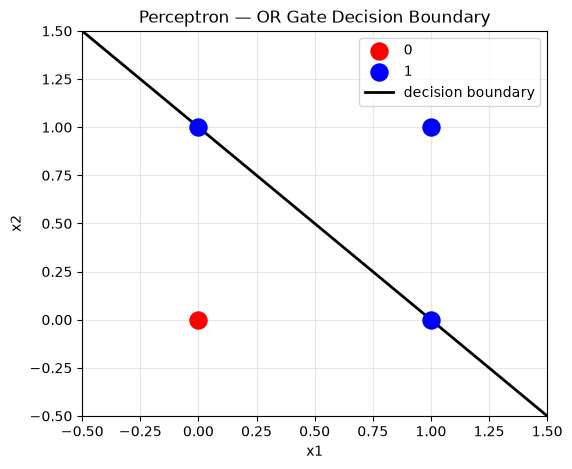

In [3]:
# Cell 3 — Version 2: OR gate + decision boundary plot
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0, 1, 1, 1])   # OR gate

w = np.zeros(2); b = 0.0; lr = 0.1

for epoch in range(20):
    errors = 0
    for xi, yi in zip(X, y):
        y_pred = step(np.dot(w, xi) + b)
        error  = yi - y_pred
        w += lr * error * xi
        b += lr * error
        errors += int(error != 0)
    if errors == 0:
        print(f"Converged at epoch {epoch+1} ✅"); break

# decision boundary: w0*x1 + w1*x2 + b = 0 → x2 = (-w0*x1 - b) / w1
x1_range = np.linspace(-0.5, 1.5, 100)
x2_bound = (-w[0]*x1_range - b) / w[1]

plt.figure(figsize=(6, 5))
plt.scatter(X[y==0,0], X[y==0,1], c='red',  s=150, label='0', zorder=5)
plt.scatter(X[y==1,0], X[y==1,1], c='blue', s=150, label='1', zorder=5)
plt.plot(x1_range, x2_bound, 'k-', linewidth=2, label='decision boundary')
plt.xlim(-0.5, 1.5); plt.ylim(-0.5, 1.5)
plt.xlabel('x1'); plt.ylabel('x2')
plt.title('Perceptron — OR Gate Decision Boundary')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

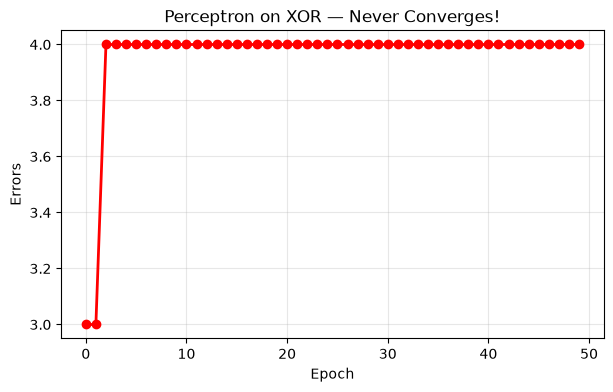

XOR is not linearly separable → need multi-layer network ✅
This is why we need Neural Networks with hidden layers!


In [4]:
# Cell 4 — Version 3: XOR gate — why perceptron fails
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y = np.array([0, 1, 1, 0])   # XOR — NOT linearly separable!

w = np.zeros(2); b = 0.0; lr = 0.1
errors_per_epoch = []

for epoch in range(50):
    errors = 0
    for xi, yi in zip(X, y):
        y_pred = step(np.dot(w, xi) + b)
        error  = yi - y_pred
        w += lr * error * xi
        b += lr * error
        errors += int(error != 0)
    errors_per_epoch.append(errors)

plt.figure(figsize=(7, 4))
plt.plot(errors_per_epoch, 'r-o', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Errors')
plt.title('Perceptron on XOR — Never Converges!')
plt.grid(True, alpha=0.3); plt.show()
print("XOR is not linearly separable → need multi-layer network ✅")
print("This is why we need Neural Networks with hidden layers!")

Final test accuracy: 52.5%


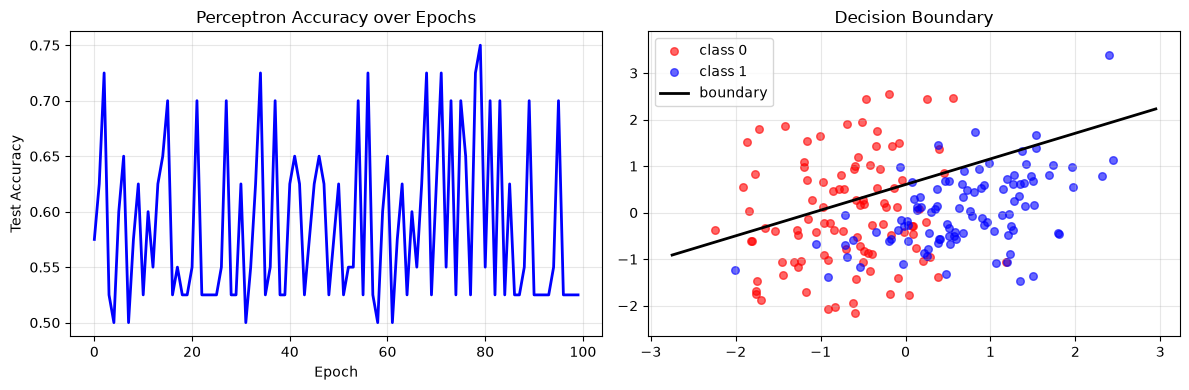

In [5]:
# Cell 5 — Version 4: perceptron on real data (binary classification)
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42,
                            n_clusters_per_class=1)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2, random_state=42)

w = np.zeros(2); b = 0.0; lr = 0.01
accs = []

for epoch in range(100):
    for xi, yi in zip(X_train, y_train):
        y_pred = step(np.dot(w, xi) + b)
        error  = yi - y_pred
        w += lr * error * xi
        b += lr * error
    preds = np.array([step(np.dot(w, xi) + b) for xi in X_test])
    accs.append(np.mean(preds == y_test))

print(f"Final test accuracy: {accs[-1]*100:.1f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(accs, 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Test Accuracy')
plt.title('Perceptron Accuracy over Epochs')
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
x1r = np.linspace(X[:,0].min()-0.5, X[:,0].max()+0.5, 300)
x2b = (-w[0]*x1r - b) / w[1]
plt.scatter(X[y==0,0], X[y==0,1], c='red',  s=30, alpha=0.6, label='class 0')
plt.scatter(X[y==1,0], X[y==1,1], c='blue', s=30, alpha=0.6, label='class 1')
plt.plot(x1r, x2b, 'k-', linewidth=2, label='boundary')
plt.ylim(X[:,1].min()-0.5, X[:,1].max()+0.5)
plt.title('Decision Boundary'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()